# Phase 2: Exploratory Analysis, Multi-Dataset Validation & Visual Storytelling

**Narrative Focus:** Exploring how health, metabolic, lifestyle, and socioeconomic patterns differ across diabetes status, and identifying the strongest associations within the 2015 BRFSS population.

### Analytical Question
What patterns distinguish people with no diabetes, prediabetes, and diabetes, and how do metabolic health, lifestyle, socioeconomic conditions, and health burden intersect?

> **Important:** The BRFSS 2015 dataset is cross-sectional, so these analyses identify associations and prevalence patterns rather than causal relationships or longitudinal disease progression.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({"font.size": 11})

# Project root
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Load the full processed datasets
df_full = pd.read_csv(
    PROCESSED_DIR / "diabetes_full_cleaned.csv"
)

df_prog = pd.read_csv(
    PROCESSED_DIR / "diabetes_progression_cleaned.csv"
)

df_bal = pd.read_csv(
    PROCESSED_DIR / "diabetes_balanced_cleaned.csv"
)

print("Datasets loaded successfully.")
print(f"Full dataset:     {df_full.shape}")
print(f"Progression data: {df_prog.shape}")
print(f"Balanced dataset: {df_bal.shape}")

Datasets loaded successfully.
Full dataset:     (253680, 27)
Progression data: (253680, 27)
Balanced dataset: (70692, 27)


## Insight 1: Metabolic and Functional Health Patterns Across Diabetes Status

How do hypertension, high cholesterol, obesity, and difficulty walking differ across people with no diabetes, prediabetes, and diabetes?

Rather than tracking individuals over time, this cross-sectional comparison shows how these health characteristics vary across diabetes-status groups in the 2015 BRFSS population.

In [3]:
# Compare key health characteristics across diabetes-status groups

status_labels = {
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
}

prog_metrics = (
    df_prog
    .groupby("Diabetes_012")[["HighBP", "HighChol", "DiffWalk"]]
    .mean()
    .mul(100)
)

# Add obesity prevalence using the engineered feature
prog_metrics["Obesity (%)"] = (
    df_prog.groupby("Diabetes_012")["Is_Obese"]
    .mean()
    .mul(100)
)

# Rename the remaining columns for readability
prog_metrics = prog_metrics.rename(columns={
    "HighBP": "High BP (%)",
    "HighChol": "High Cholesterol (%)",
    "DiffWalk": "Difficulty Walking (%)"
})

prog_metrics.index = prog_metrics.index.map(status_labels)

print("Health characteristics by diabetes status (%):\n")
print(prog_metrics.round(1))

Health characteristics by diabetes status (%):

              High BP (%)  High Cholesterol (%)  Difficulty Walking (%)  \
Diabetes_012                                                              
No Diabetes          37.1                  37.9                    13.2   
Prediabetes          62.9                  62.1                    27.7   
Diabetes             75.3                  67.0                    37.1   

              Obesity (%)  
Diabetes_012               
No Diabetes          30.4  
Prediabetes          51.6  
Diabetes             58.2  


## Insight 2: A Stronger Metabolic Factor Gradient

How does the prevalence of prediabetes or diabetes change as the number of metabolic factors increases?

We examine a project-defined count of three factors:

- High blood pressure
- High cholesterol
- Obesity

The analysis uses a chi-square test to assess association and an odds ratio to compare the highest and lowest factor groups. These results describe an association in the cross-sectional dataset and should not be interpreted as causal effects.

In [4]:
# Association between metabolic factor count and prediabetes/diabetes

contingency_metabolic = pd.crosstab(
    df_full["Metabolic_Factor_Count"],
    df_full["Diabetes_binary"]
)

# Chi-square test of association
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_metabolic
)

# Cramér's V effect size
n = contingency_metabolic.to_numpy().sum()
min_dimension = min(
    contingency_metabolic.shape[0] - 1,
    contingency_metabolic.shape[1] - 1
)

cramers_v = np.sqrt(
    (chi2 / n) / min_dimension
)

# Prevalence by metabolic factor count
metabolic_prevalence = (
    df_full
    .groupby("Metabolic_Factor_Count")["Diabetes_binary"]
    .mean()
    .mul(100)
)

# Odds ratio: 3 factors vs 0 factors
table_0_3 = contingency_metabolic.loc[[0, 3]]

noncase_0 = table_0_3.loc[0, 0]
case_0 = table_0_3.loc[0, 1]
noncase_3 = table_0_3.loc[3, 0]
case_3 = table_0_3.loc[3, 1]

odds_ratio = (case_3 / noncase_3) / (case_0 / noncase_0)

# 95% CI for the odds ratio
log_or_se = np.sqrt(
    1 / case_3 +
    1 / noncase_3 +
    1 / case_0 +
    1 / noncase_0
)

log_or = np.log(odds_ratio)

or_ci_low = np.exp(log_or - 1.96 * log_or_se)
or_ci_high = np.exp(log_or + 1.96 * log_or_se)

# Display results
print("Metabolic Factor Count Association")
print("-" * 45)

print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.3e}")
print(f"Cramér's V:           {cramers_v:.3f}")

print("\nPrevalence of prediabetes/diabetes by factor count:")
print(metabolic_prevalence.round(1).to_string())

print("\nOdds ratio: 3 factors vs 0 factors")
print(f"OR:                    {odds_ratio:.2f}")
print(f"95% CI:                {or_ci_low:.2f} – {or_ci_high:.2f}")

Metabolic Factor Count Association
---------------------------------------------
Chi-square statistic: 28,276.53
Degrees of freedom:   3
p-value:              0.000e+00
Cramér's V:           0.334

Prevalence of prediabetes/diabetes by factor count:
Metabolic_Factor_Count
0     2.9
1     9.1
2    20.9
3    39.3

Odds ratio: 3 factors vs 0 factors
OR:                    21.87
95% CI:                20.84 – 22.96


## Insight 3: The Socioeconomic Gradient Persists Across Obesity Status

Does the prevalence of prediabetes or diabetes differ across income groups, and does the pattern remain visible among obese and non-obese participants?

We compare prevalence across the eight income categories separately for obese and non-obese participants.

> **Interpretation:** This analysis identifies an income-associated prevalence gradient. It does not establish that income causes differences in diabetes status.

In [5]:
# Examine diabetes-status prevalence across income and obesity groups

socio_grad = (
    df_full
    .groupby(["Income", "Is_Obese"])["Diabetes_binary"]
    .mean()
    .unstack()
    .mul(100)
)

socio_grad = socio_grad.rename(columns={
    0: "Non-Obese Prevalence (%)",
    1: "Obese Prevalence (%)"
})

print("Prediabetes/diabetes prevalence by income and obesity status (%):\n")
print(socio_grad.round(1))

Prediabetes/diabetes prevalence by income and obesity status (%):

Is_Obese  Non-Obese Prevalence (%)  Obese Prevalence (%)
Income                                                  
1                             16.3                  35.1
2                             18.5                  36.4
3                             15.0                  33.3
4                             13.9                  30.2
5                             11.9                  26.6
6                              9.6                  23.1
7                              7.6                  20.7
8                              5.0                  15.2


## Insight 4: Diabetes Status Is Associated With Greater Health Burden

How do self-reported physical and mental health difficulties differ between people with and without prediabetes/diabetes?

We compare average `PhysHlth` and `MentHlth` values between the two groups. We also examine a project-defined `Combined_Health_Burden` measure, calculated as the sum of these two variables.

> **Important:** `PhysHlth` and `MentHlth` measure the number of days in the past 30 days when physical or mental health was not good. The combined measure is an exploratory summary and should not be interpreted as a literal number of unique days, because the two measures can overlap.

In [6]:
# Compare self-reported physical and mental health burden

burden = (
    df_full
    .groupby("Diabetes_binary")[
        ["PhysHlth", "MentHlth", "Combined_Health_Burden"]
    ]
    .mean()
)

burden.index = [
    "No Prediabetes/Diabetes",
    "Prediabetes/Diabetes"
]

burden = burden.rename(columns={
    "PhysHlth": "Average PhysHlth Days",
    "MentHlth": "Average MentHlth Days",
    "Combined_Health_Burden": "Combined Health Burden"
})

print("Average self-reported health burden:\n")
print(burden.round(1))

Average self-reported health burden:

                         Average PhysHlth Days  Average MentHlth Days  \
No Prediabetes/Diabetes                    3.6                    3.0   
Prediabetes/Diabetes                       8.0                    4.5   

                         Combined Health Burden  
No Prediabetes/Diabetes                     6.6  
Prediabetes/Diabetes                       12.4  


## Insight 5: Healthy-Habit Patterns and Prediabetes/Diabetes Prevalence

Does prediabetes/diabetes prevalence differ according to the number of healthy lifestyle behaviors reported?

We use `Healthy_Habits`, a **project-defined exploratory index from 0–4**, counting four reported behaviors:

- Regular physical activity
- Fruit consumption
- Vegetable consumption
- Non-smoking

We compare the pattern in the full population with the balanced 50–50 dataset as a sensitivity check.

> **Important:** This index is not a validated clinical score, and the observed pattern should be interpreted as an association rather than evidence that these behaviors independently prevent diabetes.

In [7]:
# Compare prediabetes/diabetes prevalence across the project-defined
# healthy-habits index in the full and balanced datasets

habits_full = (
    df_full
    .groupby("Healthy_Habits")["Diabetes_binary"]
    .mean()
    .mul(100)
)

habits_bal = (
    df_bal
    .groupby("Healthy_Habits")["Diabetes_binary"]
    .mean()
    .mul(100)
)

habit_comparison = pd.DataFrame({
    "Full Sample Prevalence (%)": habits_full,
    "Balanced Sample Prevalence (%)": habits_bal
})

habit_comparison.index.name = "Healthy Habits (0–4)"

print("Prediabetes/diabetes prevalence by healthy-habits index:\n")
print(habit_comparison.round(1))

Prediabetes/diabetes prevalence by healthy-habits index:

                      Full Sample Prevalence (%)  \
Healthy Habits (0–4)                               
0                                           22.4   
1                                           20.6   
2                                           17.2   
3                                           13.2   
4                                            8.9   

                      Balanced Sample Prevalence (%)  
Healthy Habits (0–4)                                  
0                                               63.5  
1                                               61.7  
2                                               55.9  
3                                               48.6  
4                                               37.6  


## Publication Dashboard Generation
Exporting comprehensive visual figures to `figures/` for presentation slides and documentary cutaways.

C:\Users\sandr\AppData\Local\Temp\ipykernel_16884\2149381492.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='Diabetes_binary', y='BMI', palette=['#3274a1', '#e1812c'], ax=axes[1], width=0.4)
C:\Users\sandr\AppData\Local\Temp\ipykernel_16884\2149381492.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])


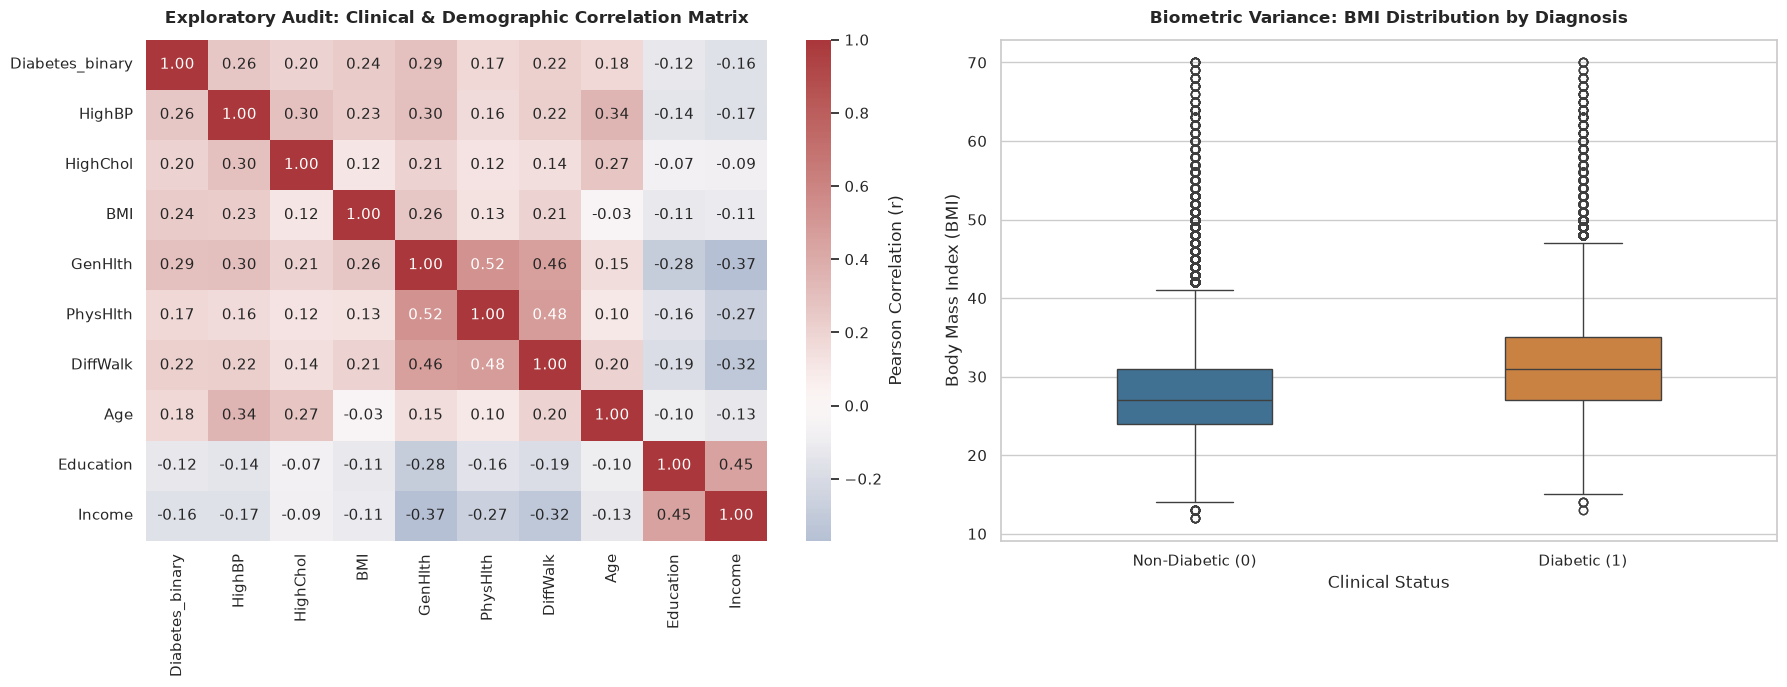

In [10]:
# -------------------------------------------------------------
# Figure 1: Exploratory Feature Landscape & Correlation Heatmap
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: Correlation Matrix Heatmap
eda_features = ['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']
corr_mat = df_full[eda_features].corr()

sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0], cbar_kws={'label': 'Pearson Correlation (r)'})
axes[0].set_title("Exploratory Audit: Clinical & Demographic Correlation Matrix", fontsize=12, fontweight='bold', pad=12)

# Subplot 2: BMI Distribution & Leverage
sns.boxplot(data=df_full, x='Diabetes_binary', y='BMI', palette=['#3274a1', '#e1812c'], ax=axes[1], width=0.4)
axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
axes[1].set_title("Biometric Variance: BMI Distribution by Diagnosis", fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel("Body Mass Index (BMI)")
axes[1].set_xlabel("Clinical Status")

plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/fig1_exploratory_landscape.png", dpi=300)
plt.show()

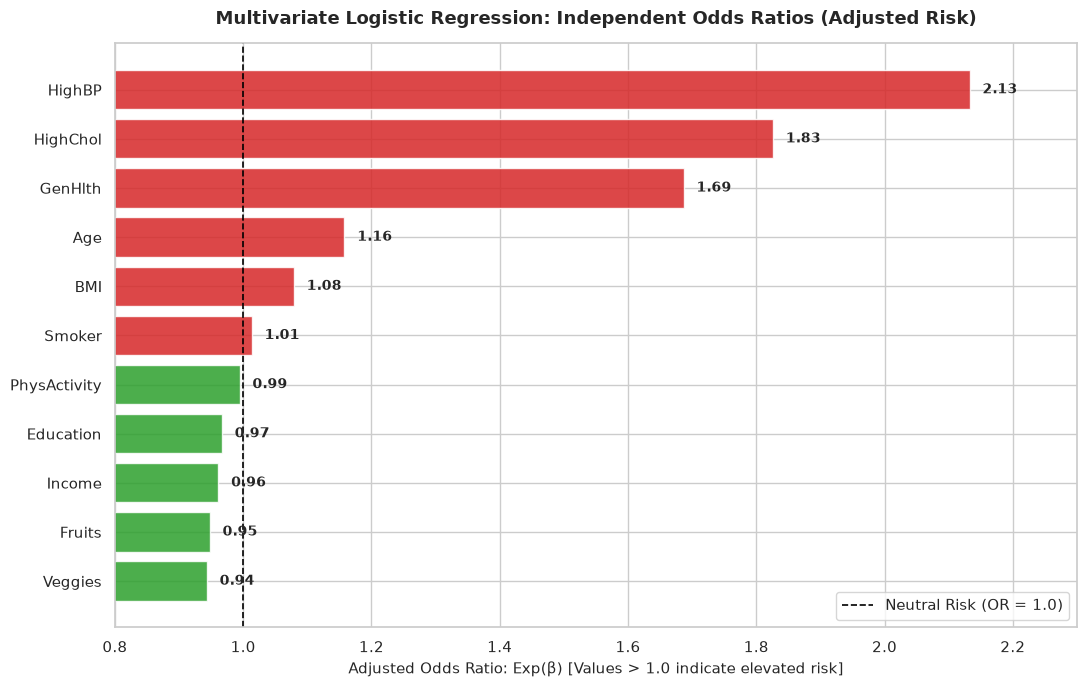

In [12]:
# -------------------------------------------------------------
# Figure 3: Multivariate Risk Analysis (Adjusted Odds Ratios)
# -------------------------------------------------------------
import statsmodels.api as sm

# Define independent risk variables
covariates = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'Age', 'Education', 'Income']
X = sm.add_constant(df_full[covariates])
y = df_full['Diabetes_binary']

logit_res = sm.Logit(y, X).fit(disp=False)
odds_ratios = pd.DataFrame({
    'Odds_Ratio': np.exp(logit_res.params),
    'p_value': logit_res.pvalues
}).drop('const').sort_values('Odds_Ratio', ascending=True)

# Generate Forest Plot
plt.figure(figsize=(11, 7))
bar_colors = ['#2ca02c' if val < 1.0 else '#d62728' for val in odds_ratios['Odds_Ratio']]
plt.barh(odds_ratios.index, odds_ratios['Odds_Ratio'], color=bar_colors, alpha=0.85)
plt.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Neutral Risk (OR = 1.0)')

plt.title("Multivariate Logistic Regression: Independent Odds Ratios (Adjusted Risk)", fontsize=13, fontweight='bold', pad=14)
plt.xlabel("Adjusted Odds Ratio: Exp(β) [Values > 1.0 indicate elevated risk]", fontsize=11)
plt.xlim(0.8, 2.3)
plt.legend(frameon=True)

for idx, val in enumerate(odds_ratios['Odds_Ratio']):
    plt.text(val + 0.02, idx, f"{val:.2f}", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("../figures/fig3_multivariate_odds_ratios.png", dpi=300)
plt.show()

C:\Users\sandr\AppData\Local\Temp\ipykernel_16884\1705102668.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=triad_prev.index, y=triad_prev.values, ax=ax1, palette="Reds_d")
C:\Users\sandr\AppData\Local\Temp\ipykernel_16884\1705102668.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=habits_full.index, y=habits_full.values, ax=ax4, palette="Greens_r")


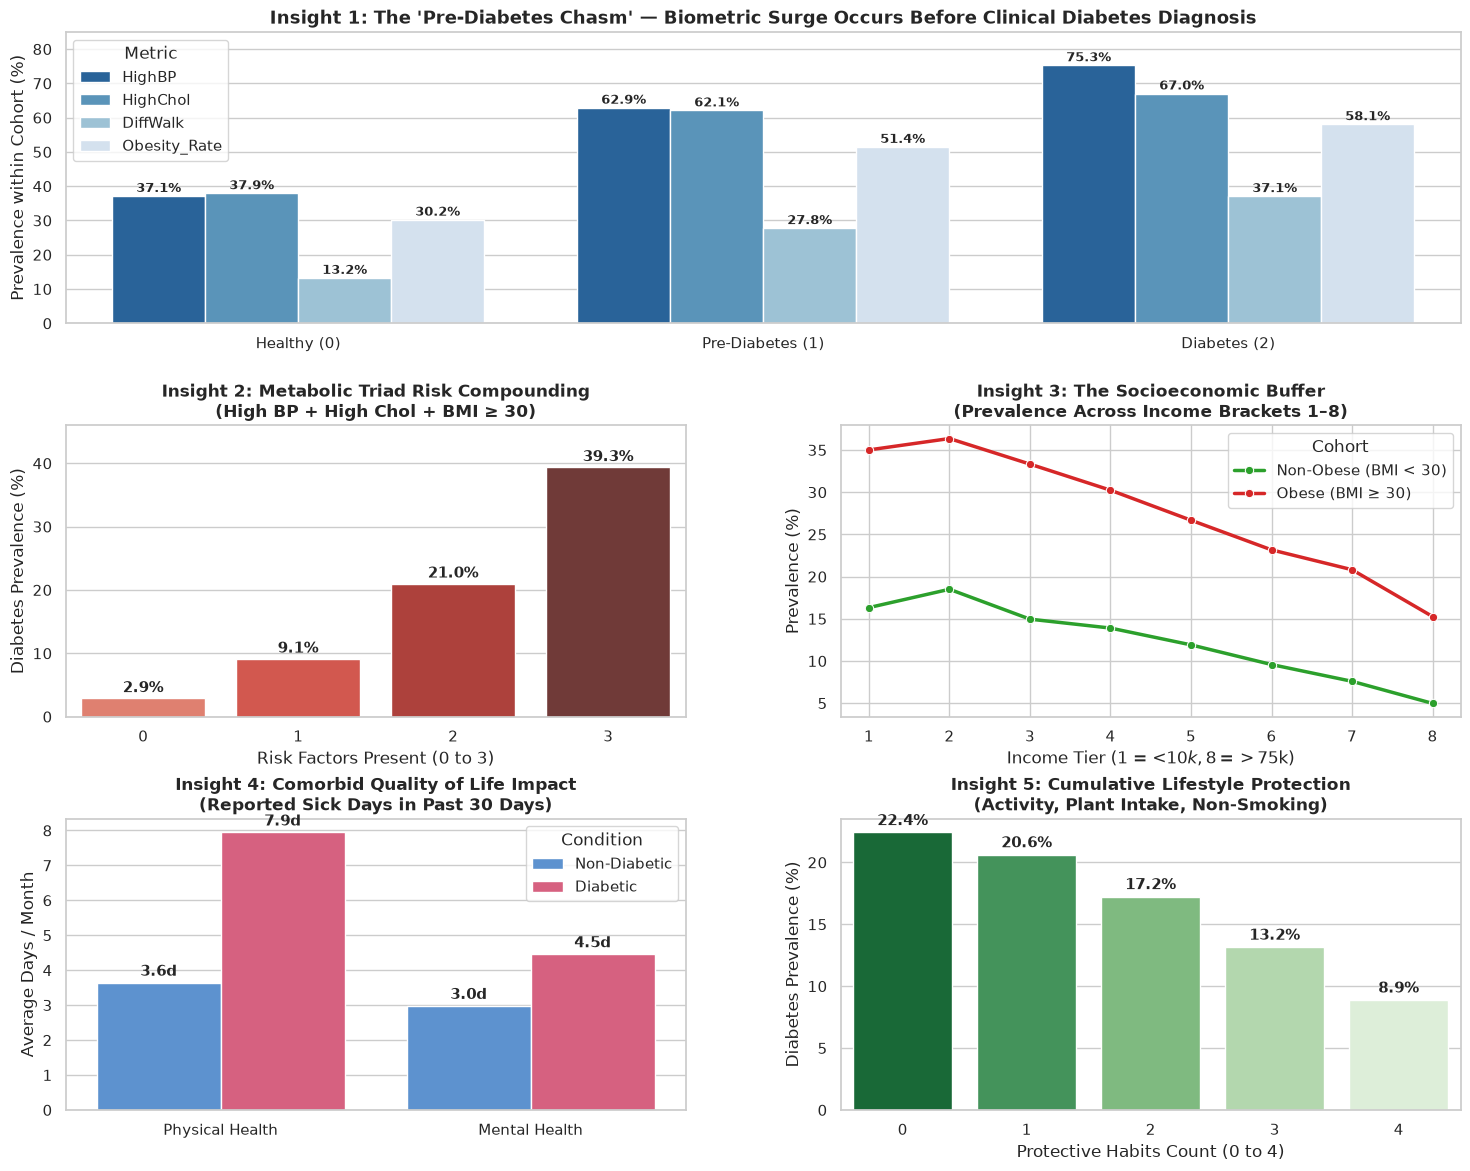

In [9]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)

# 1. Progression Chart
ax0 = fig.add_subplot(gs[0, :])
prog_plot_data = prog_metrics.reset_index().melt(id_vars='index', var_name='Metric', value_name='Prevalence')
sns.barplot(data=prog_plot_data, x='index', y='Prevalence', hue='Metric', ax=ax0, palette='Blues_r')
ax0.set_title("Insight 1: The 'Pre-Diabetes Chasm' — Biometric Surge Occurs Before Clinical Diabetes Diagnosis", fontweight='bold', fontsize=13)
ax0.set_xlabel("")
ax0.set_ylabel("Prevalence within Cohort (%)")
ax0.set_ylim(0, 85)
for p in ax0.patches:
    h = p.get_height()
    if h > 0:
        ax0.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h + 1.2), ha='center', fontweight='bold', fontsize=9)

# 2. Triad Multiplier
ax1 = fig.add_subplot(gs[1, 0])
sns.barplot(x=triad_prev.index, y=triad_prev.values, ax=ax1, palette="Reds_d")
ax1.set_title("Insight 2: Metabolic Triad Risk Compounding\n(High BP + High Chol + BMI ≥ 30)", fontweight='bold')
ax1.set_xlabel("Risk Factors Present (0 to 3)")
ax1.set_ylabel("Diabetes Prevalence (%)")
ax1.set_ylim(0, 46)
for i, v in enumerate(triad_prev.values):
    ax1.text(i, v + 1.0, f"{v:.1f}%", ha='center', fontweight='bold')

# 3. Socioeconomic Gradient
ax2 = fig.add_subplot(gs[1, 1])
socio_plot = df_full.groupby(['Income', 'Is_Obese'])['Diabetes_binary'].mean().reset_index()
socio_plot['Prevalence'] = socio_plot['Diabetes_binary'] * 100
socio_plot['Cohort'] = socio_plot['Is_Obese'].map({1: 'Obese (BMI ≥ 30)', 0: 'Non-Obese (BMI < 30)'})
sns.lineplot(data=socio_plot, x='Income', y='Prevalence', hue='Cohort', marker='o', linewidth=2.5, ax=ax2, palette=['#2ca02c', '#d62728'])
ax2.set_title("Insight 3: The Socioeconomic Buffer\n(Prevalence Across Income Brackets 1–8)", fontweight='bold')
ax2.set_xlabel("Income Tier (1 = <$10k, 8 = >$75k)")
ax2.set_ylabel("Prevalence (%)")

# 4. Sick Days Disparity
ax3 = fig.add_subplot(gs[2, 0])
burden_df = df_full.groupby('Diabetes_binary')[['PhysHlth', 'MentHlth']].mean().reset_index()
burden_df['Condition'] = burden_df['Diabetes_binary'].map({0: 'Non-Diabetic', 1: 'Diabetic'})
burden_melt = burden_df.melt(id_vars='Condition', value_vars=['PhysHlth', 'MentHlth'], var_name='Dim', value_name='Days')
burden_melt['Dim'] = burden_melt['Dim'].map({'PhysHlth': 'Physical Health', 'MentHlth': 'Mental Health'})
sns.barplot(data=burden_melt, x='Dim', y='Days', hue='Condition', ax=ax3, palette=['#4a90e2', '#e94e77'])
ax3.set_title("Insight 4: Comorbid Quality of Life Impact\n(Reported Sick Days in Past 30 Days)", fontweight='bold')
ax3.set_xlabel("")
ax3.set_ylabel("Average Days / Month")
for p in ax3.patches:
    h = p.get_height()
    if h > 0:
        ax3.annotate(f"{h:.1f}d", (p.get_x() + p.get_width() / 2., h + 0.2), ha='center', fontweight='bold')

# 5. Lifestyle Shield Comparison
ax4 = fig.add_subplot(gs[2, 1])
sns.barplot(x=habits_full.index, y=habits_full.values, ax=ax4, palette="Greens_r")
ax4.set_title("Insight 5: Cumulative Lifestyle Protection\n(Activity, Plant Intake, Non-Smoking)", fontweight='bold')
ax4.set_xlabel("Protective Habits Count (0 to 4)")
ax4.set_ylabel("Diabetes Prevalence (%)")
for i, v in enumerate(habits_full.values):
    ax4.text(i, v + 0.6, f"{v:.1f}%", ha='center', fontweight='bold')

os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/diabetes_comprehensive_dashboard.png", dpi=300)
plt.show()